# Bank Marketing EDA

## 1. Problem Definition and Data-Generating Process

### 1.1 Business Problem

The objective is to identify clients who are more likely to subscribe to a bank term deposit before a marketing call is made.

The prediction will be used to prioritize clients when marketing resources, such as available call-center agents, are limited.

Rather than treating the task only as a binary classification problem, the model should ideally produce a probability or ranking that can support client prioritization.

### 1.2 Prediction Target

The target variable is:

- `y = "yes"`: the client subscribed to a term deposit.
- `y = "no"`: the client did not subscribe to a term deposit.

This is a binary classification problem.

### 1.3 Prediction Timestamp

The intended prediction time is immediately before a marketing call is made.

Conceptually:

Client information and historical information
→ Model prediction
→ Marketing call
→ Call outcome
→ Term-deposit subscription outcome

Only information that is available before the marketing call should be used
as model input.

According to the dataset documentation, `duration` records the duration of
the current marketing call. Because this information is only available after
the call has taken place, `duration` will not be used as a modeling feature.

### 1.4 Unit of Observation

Each row represents a marketing campaign observation associated with a bank client.

A row contains a combination of:

- client characteristics
- current campaign information
- previous campaign history
- social and economic context
- subscription outcome

The dataset does not contain a unique client identifier, so repeated observations from the same client cannot be directly identified.

### 1.5 Data-Generating Process

The dataset was collected from direct marketing campaigns conducted by a Portuguese banking institution.

A simplified data-generating process is:

1. The bank has information about a client.
2. A marketing campaign targets the client.
3. The client may be contacted one or more times.
4. Contact-related information is recorded.
5. The client either subscribes or does not subscribe to a term deposit.
6. The final campaign record is stored in the dataset.

Some variables may therefore be generated before the prediction time, while others may only become known during or after the marketing contact.

This distinction will be important when checking feature availability and data leakage.

### 1.6 Business Decision

The model will not be used only to predict a label.

The intended decision is to prioritize clients for marketing calls.

For example, if only a limited number of clients can be contacted, clients with the highest predicted subscription probabilities could be contacted first.

Therefore, probability ranking, threshold selection, and top-k decision rules may be more relevant than classification accuracy alone.

## 2. Dataset Overview and Schema

This section examines the basic structure of the dataset.

The goals are to:

- confirm the dataset shape
- inspect sample observations
- inspect column names
- inspect data types
- identify numeric and categorical variables
- confirm the target variable

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROJECT_ROOT

PosixPath('/home/moonk/projects/bank-marketing-ml')

In [3]:
RAW_DATA_PATH = (
    PROJECT_ROOT
     / "data"
     / "raw"
     / "bank-additional"
     / "bank-additional-full.csv"
    )

RAW_DATA_PATH

PosixPath('/home/moonk/projects/bank-marketing-ml/data/raw/bank-additional/bank-additional-full.csv')

In [4]:
df = pd.read_csv(RAW_DATA_PATH, sep=";")

In [5]:
df.shape

(41188, 21)

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [8]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [10]:
target = "y"
excluded_features = ["duration"]

In [11]:
numeric_features = [
    col
    for col in df.select_dtypes(include="number").columns
    if col not in excluded_features
]

numeric_features

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [12]:
categorical_features = [
    col
    for col in df.select_dtypes(include=["object", "string"]).columns
    if col != target
]

categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [13]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [14]:
len(numeric_features), len(categorical_features)

(9, 10)

### Observations

- The dataset contains 41,188 rows and 21 columns.
- There are 20 original input variables and 1 target variable.
- The target variable is `y`.
- `duration` is retained in the raw dataset but excluded from the modeling feature set based on the prediction-time definition established in Section 1.
- The resulting modeling feature set contains 19 variables:
  - 9 numeric features
  - 10 categorical features
- The dataset contains a mix of client attributes, campaign-related variables, previous campaign information, and macroeconomic variables.

## 3. Split Strategy and Data Splitting

This section defines the train, validation, and test sets before performing
modeling-oriented exploratory analysis.

The goals are to:

- examine the temporal structure of the dataset
- determine whether a random split is appropriate
- examine temporal changes in the target distribution
- create train, validation, and test sets that reflect the intended deployment setting

In [15]:
df["month"].head(10)

0    may
1    may
2    may
3    may
4    may
5    may
6    may
7    may
8    may
9    may
Name: month, dtype: str

In [16]:
month_changes = df.loc[
    df["month"].ne(df["month"].shift()),
    ["month"],
]

month_changes

,month
0,may
7763,jun
12137,jul
18822,aug
23997,oct
24064,nov
27680,dec
27690,mar
27972,apr
30430,may


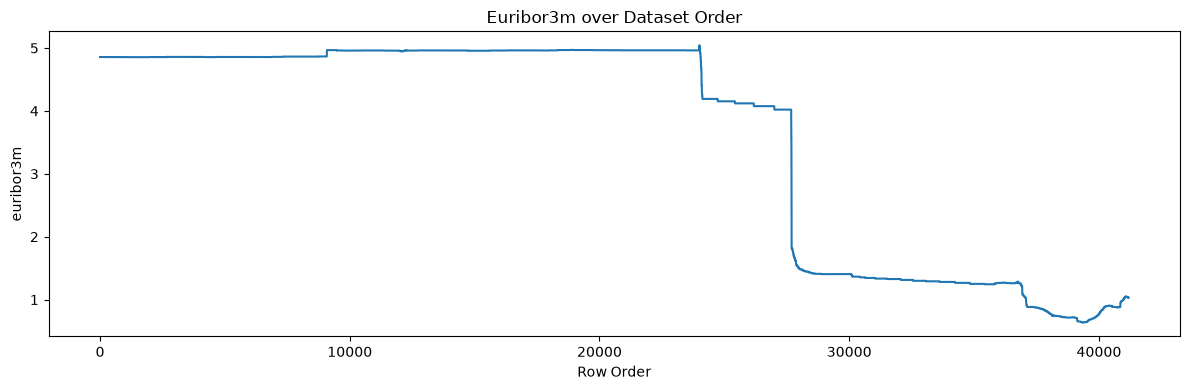

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    df.index,
    df["euribor3m"],
)

plt.xlabel("Row Order")
plt.ylabel("euribor3m")
plt.title("Euribor3m over Dataset Order")
plt.tight_layout()
plt.show()

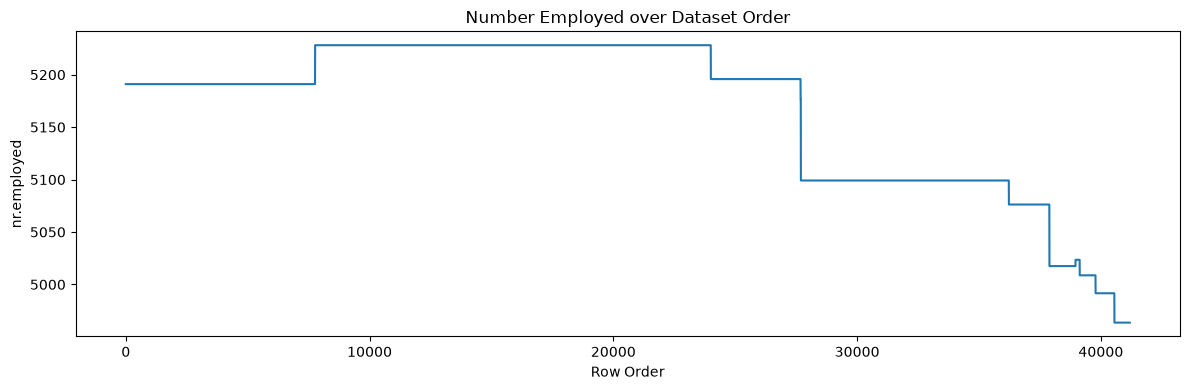

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(
    df.index,
    df["nr.employed"],
)

plt.xlabel("Row Order")
plt.ylabel("nr.employed")
plt.title("Number Employed over Dataset Order")
plt.tight_layout()
plt.show()

### Why a Chronological Split?

The intended deployment setting is temporal:

historical observations
→ model development
→ prediction on future observations

Several variables, particularly the macroeconomic indicators, change
systematically over the dataset order.

A random split would mix observations from different temporal regimes across
the training and evaluation sets.

Therefore, chronological splitting is preferred to better approximate future
deployment.

In [19]:
split_diagnostic = df.copy()

split_diagnostic["time_block"] = pd.qcut(
    split_diagnostic.index,
    q=10,
    labels=False,
)

target_rate_by_block = (
    split_diagnostic
    .assign(y_yes=split_diagnostic[target].eq("yes"))
    .groupby("time_block")["y_yes"]
    .agg(["mean", "count"])
)

target_rate_by_block

,mean,count
time_block,,
0,0.027677,4119
1,0.035203,4119
2,0.042243,4119
3,0.066294,4118
4,0.062394,4119
5,0.054625,4119
6,0.101506,4118
7,0.119932,4119
8,0.157320,4119


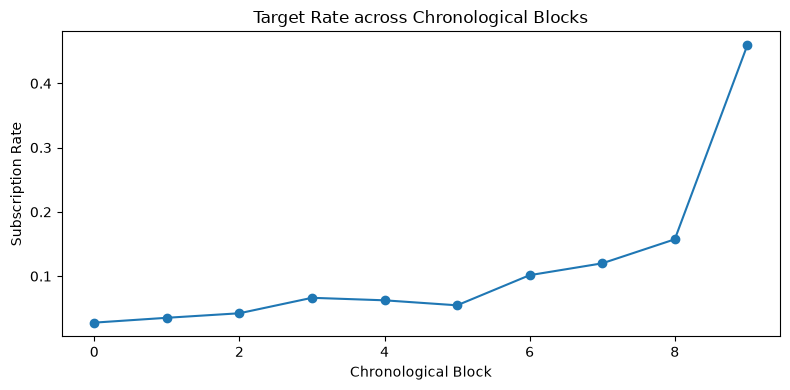

In [20]:
plt.figure(figsize=(8, 4))

plt.plot(
    target_rate_by_block.index,
    target_rate_by_block["mean"],
    marker="o",
)

plt.xlabel("Chronological Block")
plt.ylabel("Subscription Rate")
plt.title("Target Rate across Chronological Blocks")
plt.tight_layout()
plt.show()

In [21]:
n = len(df)

train_end = int(n * 0.70)
valid_end = int(n * 0.90)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

In [22]:
print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (28831, 21)
Validation: (8238, 21)
Test: (4119, 21)


In [23]:
def target_rate(data):
    return (data[target] == "yes").mean()


for name, data in [
    ("train", train_df),
    ("validation", valid_df),
    ("test", test_df),
]:
    print(
        name,
        data.shape,
        target_rate(data),
    )

train (28831, 21) 0.055703929797787106
validation (8238, 21) 0.13862588006797766
test (4119, 21) 0.4593347899975722


### Observations

- The dataset exhibits clear temporal structure across the original row order.
- Macroeconomic variables such as `euribor3m` and `nr.employed` change systematically over the dataset order.
- The target subscription rate also changes substantially across chronological blocks, indicating strong temporal distribution shift.
- A random or stratified split would mix observations from different temporal regimes and would not reflect the intended future-deployment setting.
- A chronological 70/20/10 split is therefore used:
  - Train: first 70%
  - Validation: next 20%
  - Test: final 10%
- The resulting datasets contain:
  - 28,831 training observations
  - 8,238 validation observations
  - 4,119 test observations
- The observed target rates are approximately:
  - Train: 5.57%
  - Validation: 13.86%
  - Test: 45.93%
- The large differences in target prevalence are preserved because they reflect temporal distribution shift in the data.
- From this point onward, modeling-oriented EDA will be performed using `train_df` only.
- `valid_df` will be used for model development and selection, while `test_df` will be reserved for final evaluation.

## 4. Data Quality Analysis

This section examines the training data for common data quality issues.

The goals are to examine:

- missing values
- special or unknown categories
- exact duplicate rows
- categorical cardinality
- unusual or invalid numeric values
- special sentinel values

All checks in this section are performed using `train_df` only.

### 4.1 Missing Values

In [24]:
train_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### 4.2 Special or Unknown Categories

In [25]:
for col in categorical_features:
    unknown_rate = train_df[col].eq("unknown").mean()

    if unknown_rate > 0:
        print(f"{col}: {unknown_rate:.2%}")

job: 0.86%
marital: 0.17%
education: 4.10%
default: 25.33%
housing: 2.41%
loan: 2.41%


### 4.3 Exact duplicate rows

In [26]:
train_df.duplicated().sum()

np.int64(9)

In [27]:
train_df[
    train_df.duplicated(keep=False)
]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


### 4.4 Categorical Cardinality

In [28]:
train_df[categorical_features].nunique().sort_values()

contact         2
default         3
housing         3
loan            3
poutcome        3
marital         4
day_of_week     5
education       8
month           9
job            12
dtype: int64

### 4.5 Numeric Ranges

In [29]:
train_df[numeric_features].describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,28831.000000,28831.000000,28831.000000,28831.000000,28831.000000,28831.000000,28831.000000,28831.000000,28831.000000
mean,40.177483,2.768270,997.172592,0.035899,1.000409,93.810004,-39.792935,4.685469,5208.861153
std,9.335439,3.111751,42.583054,0.192456,0.747091,0.416240,3.369460,0.704179,28.165318
min,18.000000,1.000000,0.000000,0.000000,-1.800000,92.756000,-50.000000,1.410000,5099.100000
25%,33.000000,1.000000,999.000000,0.000000,1.100000,93.444000,-42.700000,4.857000,5191.000000
50%,39.000000,2.000000,999.000000,0.000000,1.400000,93.918000,-41.800000,4.957000,5228.100000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.962000,5228.100000
max,95.000000,56.000000,999.000000,3.000000,1.400000,94.465000,-36.100000,5.045000,5228.100000


### 4.6 Special Sentinel Values

In [30]:
train_df["pdays"].value_counts().sort_index()

pdays
0          2
1          4
2          1
3          7
4          8
5         12
6         10
7          1
8          1
9          4
10         2
11         1
999    28778
Name: count, dtype: int64

In [31]:
train_df["pdays"].eq(999).mean()

np.float64(0.9981617009468975)

In [32]:
pd.crosstab(
    train_df["poutcome"],
    train_df["pdays"].eq(999),
)

pdays,False,True
poutcome,,
failure,3,949
nonexistent,0,27829
success,50,0


In [33]:
pd.crosstab(
    train_df["poutcome"],
    train_df["previous"],
)

previous,0,1,2,3
poutcome,,,,
failure,0,925,26,1
nonexistent,27829,0,0,0
success,0,46,3,1


In [34]:
pd.crosstab(
    train_df["previous"].gt(0),
    train_df["pdays"].eq(999),
)

pdays,False,True
previous,,
False,0,27829
True,53,949


### Observations

- No pandas-recognized missing values were found in the training data.
- Several categorical features contain the explicit category `"unknown"`.
- `"unknown"` is particularly common in `default` (25.33%), while smaller proportions are present in `education`, `housing`, `loan`, `job`, and `marital`.
- Exact duplicate rows are present (9 rows). They are retained because the dataset does not contain a unique client identifier, making it impossible to determine whether identical rows are duplicate records or distinct clients with identical observed attributes.
- The categorical features have relatively low cardinality.
- `month` contains 9 categories in the training data, which indicates that a temporally split future dataset may contain categories not observed during training. The preprocessing pipeline should therefore be robust to unseen categories.
- No obviously invalid numeric ranges were identified at this stage. Extreme or highly skewed values will be examined later during univariate analysis.
- `pdays` is dominated by the sentinel value `999`, which appears in approximately 99.82% of the training observations.
- `pdays = 999` cannot be interpreted simply as "no previous contact", because many observations with `previous > 0` also have `pdays = 999`.
- `pdays`, `previous`, and `poutcome` exhibit a strong structural relationship and should be interpreted together.
- No cleaning or feature transformation is applied at this stage. These findings will be carried forward to the modeling-decision stage.

## 5. Target Analysis

This section examines the distribution of the target variable `y` in the
training data.

The goals are to:

- inspect class counts
- inspect class proportions
- assess class imbalance
- identify implications for model evaluation

In [35]:
train_df[target].value_counts()

y
no     27225
yes     1606
Name: count, dtype: int64

In [36]:
train_df[target].value_counts(normalize=True)

y
no     0.944296
yes    0.055704
Name: proportion, dtype: float64

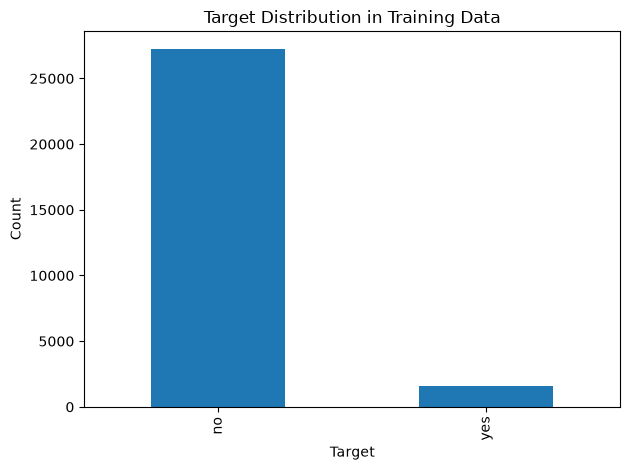

In [37]:
train_df[target].value_counts().plot(
    kind="bar",
    title="Target Distribution in Training Data",
)

plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Observations

- The training set contains 28,831 observations:
  - `no`: 27,225 observations (94.43%)
  - `yes`: 1,606 observations (5.57%)
- The target variable is therefore strongly imbalanced in the training period.
- A naive classifier that predicts `no` for every observation would achieve approximately 94.43% accuracy despite completely failing to identify potential subscribers.
- Accuracy alone is therefore not an appropriate evaluation metric.
- Precision, recall, PR-AUC, and ROC-AUC should be considered during model evaluation.
- Because the positive class is relatively rare, PR-AUC will be particularly informative for evaluating performance on potential subscribers.
- Because the business objective is to prioritize a limited number of clients for marketing calls, predicted probabilities, ranking quality, and top-k decision rules should also be evaluated.
- The positive-class prevalence changes substantially across chronological periods, so model performance should be interpreted together with temporal distribution shift.

## 6. Univariate Analysis

This section examines each modeling feature independently using the training data.

The goals are to:

- understand the distributions of numeric features
- identify skewness and extreme values
- inspect categorical frequency distributions
- identify rare or dominant categories
- identify distributional characteristics that may affect preprocessing or modeling

### 6.1 Numerical Features

In [38]:
numeric_features

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [39]:
train_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,28831.0,40.177483,9.335439,18.000,33.000,39.000,47.000,95.000
campaign,28831.0,2.768270,3.111751,1.000,1.000,2.000,3.000,56.000
pdays,28831.0,997.172592,42.583054,0.000,999.000,999.000,999.000,999.000
previous,28831.0,0.035899,0.192456,0.000,0.000,0.000,0.000,3.000
emp.var.rate,28831.0,1.000409,0.747091,-1.800,1.100,1.400,1.400,1.400
cons.price.idx,28831.0,93.810004,0.416240,92.756,93.444,93.918,93.994,94.465
cons.conf.idx,28831.0,-39.792935,3.369460,-50.000,-42.700,-41.800,-36.400,-36.100
euribor3m,28831.0,4.685469,0.704179,1.410,4.857,4.957,4.962,5.045
nr.employed,28831.0,5208.861153,28.165318,5099.100,5191.000,5228.100,5228.100,5228.100


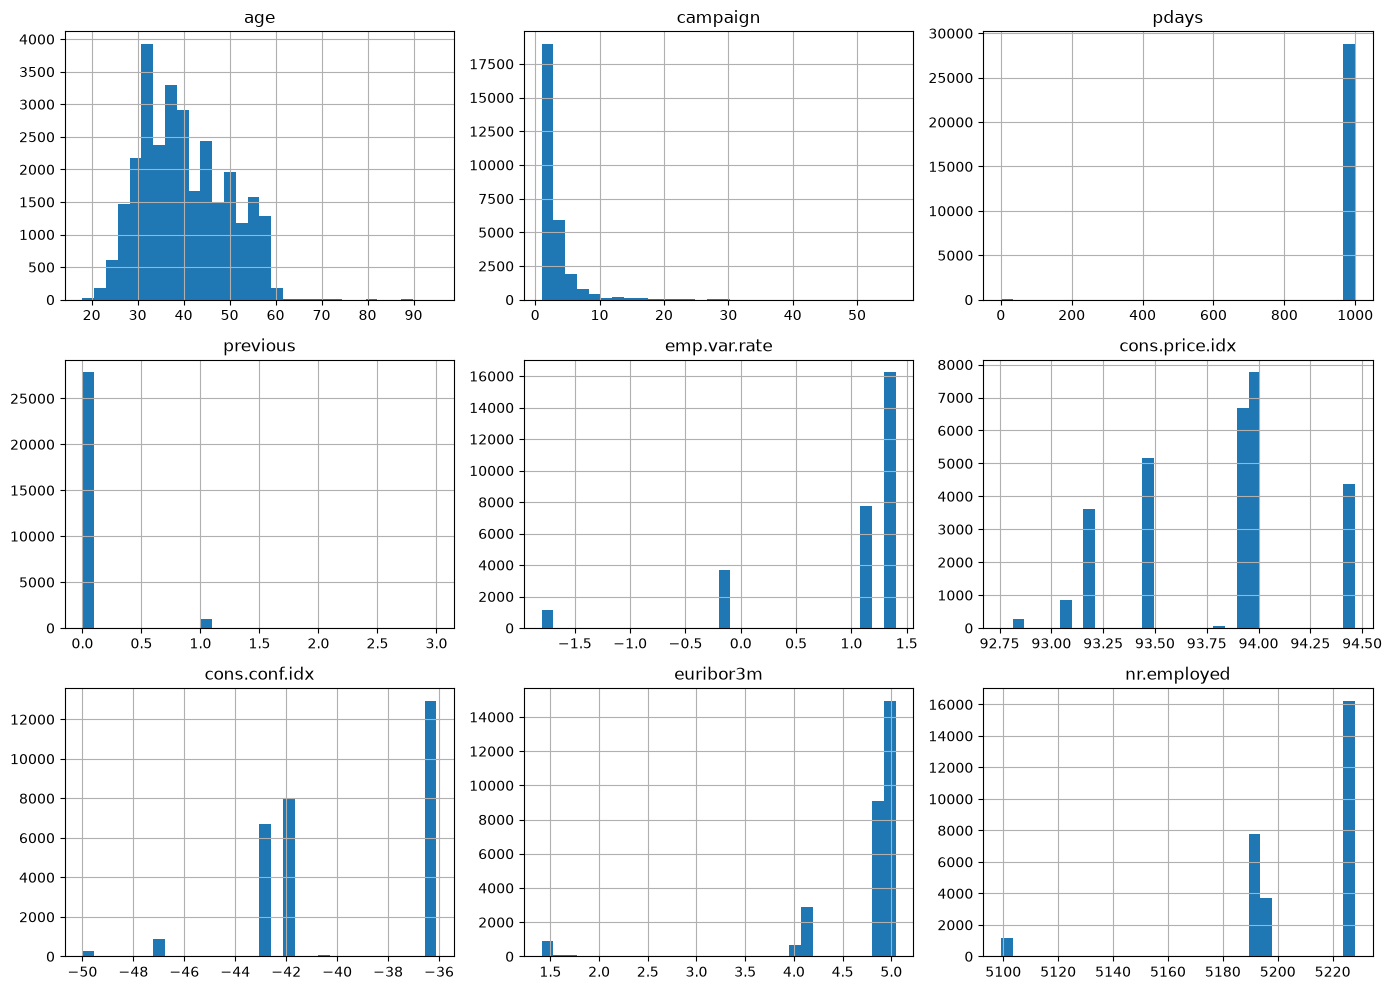

In [40]:
train_df[numeric_features].hist(
    bins=30,
    figsize=(14, 10),
)

plt.tight_layout()
plt.show()

In [41]:
numeric_skewness = (
    train_df[numeric_features]
    .skew()
    .sort_values(ascending=False)
)

numeric_skewness

previous           5.550699
campaign           4.502260
age                0.405786
cons.price.idx    -0.190676
cons.conf.idx     -0.282861
nr.employed       -2.244942
emp.var.rate      -2.407448
euribor3m         -3.744898
pdays            -23.260473
dtype: float64

In [42]:
train_df[numeric_features].quantile(
    [0.01, 0.05, 0.50, 0.95, 0.99]
).T

,0.01,0.05,0.50,0.95,0.99
age,24.000,27.000,39.000,57.000,59.000
campaign,1.000,1.000,2.000,8.000,17.000
pdays,999.000,999.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,0.000,1.000
emp.var.rate,-1.800,-0.100,1.400,1.400,1.400
cons.price.idx,92.843,93.200,93.918,94.465,94.465
cons.conf.idx,-47.100,-42.700,-41.800,-36.100,-36.100
euribor3m,1.415,4.021,4.957,4.967,4.968
nr.employed,5099.100,5191.000,5228.100,5228.100,5228.100


In [43]:
train_df["campaign"].value_counts().sort_index()

campaign
1     11619
2      7350
3      3949
4      1957
5      1166
6       717
7       487
8       311
9       243
10      204
11      158
12      115
13       89
14       68
15       47
16       49
17       57
18       33
19       26
20       30
21       24
22       17
23       15
24       15
25        8
26        8
27       11
28        8
29       10
30        7
31        7
32        4
33        4
34        3
35        5
37        1
39        1
40        2
41        1
42        2
43        2
56        1
Name: count, dtype: int64

In [44]:
train_df["previous"].value_counts().sort_index()

previous
0    27829
1      971
2       29
3        2
Name: count, dtype: int64

In [45]:
train_df["pdays"].value_counts().sort_index()

pdays
0          2
1          4
2          1
3          7
4          8
5         12
6         10
7          1
8          1
9          4
10         2
11         1
999    28778
Name: count, dtype: int64

In [46]:
train_df[
    [
        "emp.var.rate",
        "cons.price.idx",
        "cons.conf.idx",
        "euribor3m",
        "nr.employed",
    ]
].nunique().sort_values()

emp.var.rate       5
nr.employed        5
cons.conf.idx      9
cons.price.idx     9
euribor3m         93
dtype: int64

### Numeric Feature Observations

- `age` is moderately right-skewed, with a median of 39 years and a maximum of 95. The 99th percentile is 59, indicating that very high ages occur only in a small number of observations.
- `campaign` is strongly right-skewed. Most clients were contacted only a few times during the current campaign:
  - median: 2
  - 95th percentile: 8
  - 99th percentile: 17
  - maximum: 56
- `previous` is highly concentrated at zero. Approximately 95% of observations have `previous = 0`, while only a small minority have records of previous campaign contacts.
- `pdays` is almost entirely equal to the sentinel value `999` (approximately 99.82% of the training data). Its very large negative skewness is therefore an artifact of the sentinel-value structure and should not be interpreted as ordinary distributional skewness.
- The macroeconomic variables have relatively limited sets of observed values. In particular, `emp.var.rate` and `nr.employed` each contain only 5 unique values in the training period.
- Several macroeconomic variables are concentrated near one end of their observed range, resulting in substantial negative skewness. This reflects the temporal and economic regimes represented in the training period rather than conventional client-level continuous variation.
- No clearly invalid numeric values were identified.
- Extreme values and non-normal distributions are noted, but no clipping, transformation, or outlier removal is applied during EDA.

### 6.2 Categorical Features

In [47]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [48]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(
        train_df[col]
        .value_counts(normalize=True)
        .round(4)
    )


--- job ---
job
admin.           0.2465
blue-collar      0.2326
technician       0.1753
services         0.0980
management       0.0727
entrepreneur     0.0383
self-employed    0.0362
retired          0.0305
housemaid        0.0291
unemployed       0.0240
unknown          0.0086
student          0.0082
Name: proportion, dtype: float64

--- marital ---
marital
married     0.6314
single      0.2498
divorced    0.1171
unknown     0.0017
Name: proportion, dtype: float64

--- education ---
education
university.degree      0.2894
high.school            0.2240
basic.9y               0.1502
professional.course    0.1316
basic.4y               0.1058
basic.6y               0.0574
unknown                0.0410
illiterate             0.0005
Name: proportion, dtype: float64

--- default ---
default
no         0.7466
unknown    0.2533
yes        0.0001
Name: proportion, dtype: float64

--- housing ---
housing
yes        0.5081
no         0.4678
unknown    0.0241
Name: proportion, dtype: float64

-

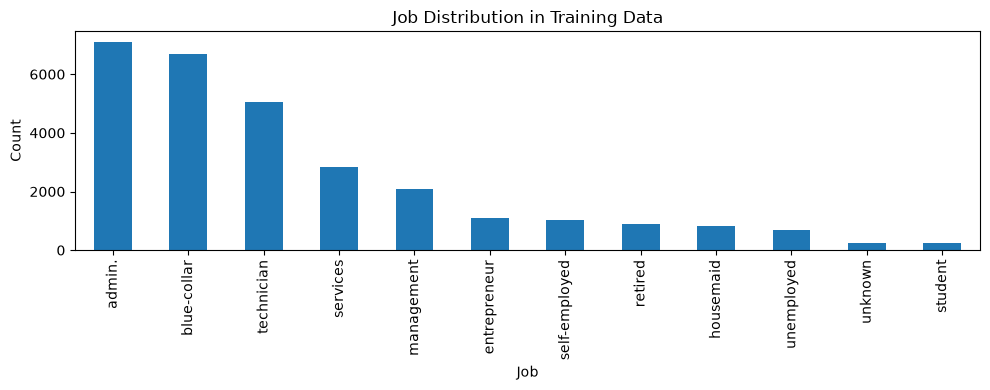

In [49]:
train_df["job"].value_counts().plot(
    kind="bar",
    figsize=(10, 4),
    title="Job Distribution in Training Data",
)

plt.xlabel("Job")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

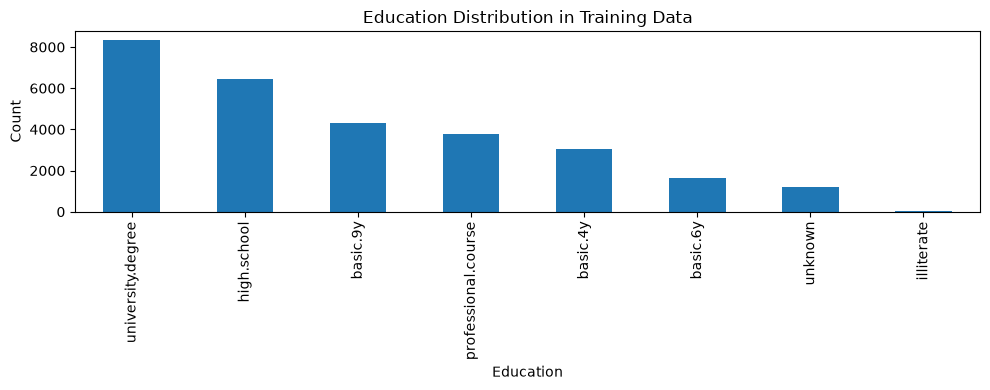

In [50]:
train_df["education"].value_counts().plot(
    kind="bar",
    figsize=(10, 4),
    title="Education Distribution in Training Data",
)

plt.xlabel("Education")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

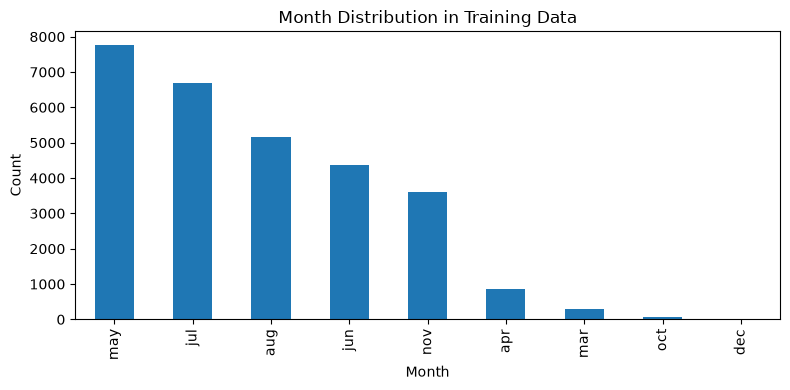

In [51]:
train_df["month"].value_counts().plot(
    kind="bar",
    figsize=(8, 4),
    title="Month Distribution in Training Data",
)

plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

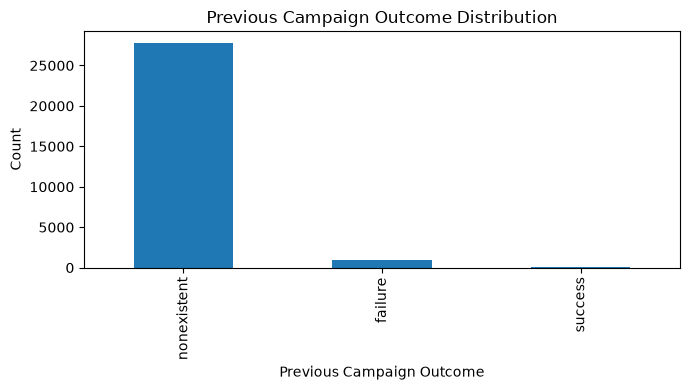

In [52]:
train_df["poutcome"].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    title="Previous Campaign Outcome Distribution",
)

plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Categorical Feature Observations

- `job` is moderately concentrated in a few categories, with `admin.`, `blue-collar`, and `technician` accounting for the largest shares of the training data.
- `marital` is dominated by `married` (63.14%), while the `"unknown"` category is very rare.
- `education` is distributed across several categories, although `university.degree` and `high.school` are the most common. The `illiterate` category is extremely rare (0.05%).
- `default` is highly imbalanced:
  - `no`: 74.66%
  - `unknown`: 25.33%
  - `yes`: approximately 0.01%
- `housing` is relatively balanced between `yes` and `no`, while `loan` is dominated by `no`.
- `contact` is relatively balanced between `cellular` and `telephone`.
- `month` is strongly concentrated in a few months, particularly `may`, `jul`, `aug`, `jun`, and `nov`. Very few observations occur in `oct` and `dec`.
- Only 9 month categories are observed in the training period, reflecting the limited temporal coverage of the chronological training split.
- `day_of_week` is relatively balanced across weekdays.
- `poutcome` is overwhelmingly dominated by `nonexistent` (96.52%), while `success` is extremely rare (0.17%).
- Several rare categories are present, but no categories are merged or removed during EDA.

### Observations

- The numeric modeling features have substantially different distributional characteristics.
- `campaign` is strongly right-skewed, with most observations concentrated at small values and a small number of much larger values.
- `previous` is highly concentrated at zero, while `pdays` is dominated by the sentinel value `999`.
- The extreme skewness of `pdays` is caused by its sentinel-value structure and should not be interpreted as ordinary continuous-variable skewness.
- Several macroeconomic features have only a small number of unique values and appear to represent temporal economic regimes rather than ordinary client-level continuous variation.
- The categorical features generally have low cardinality, but their frequency distributions vary substantially.
- `default` contains a large `"unknown"` group and an extremely rare `yes` category.
- `month` is strongly concentrated in a few categories and contains only 9 observed categories in the training period, reflecting the temporal coverage of the chronological split.
- `day_of_week`, `contact`, and `housing` are comparatively balanced.
- `poutcome` is dominated by `nonexistent`, consistent with the strong concentration of `previous = 0` and `pdays = 999`.
- Several rare categories are present, but no categories are merged or removed during EDA.
- These distributional characteristics will be considered later when designing preprocessing and selecting models.

## 7. Feature-Target Analysis

This section examines how individual modeling features are associated with
the target variable `y` in the training data.

The goals are to:

- compare target rates across categorical features
- compare numeric feature distributions across target classes
- identify potentially useful predictive relationships
- identify relationships that require cautious interpretation
- flag features whose availability at prediction time should be reviewed later

In [53]:
train_analysis = train_df.assign(
    y_yes=train_df[target].eq("yes").astype(int)
)

### 7.1 Categorical Features vs Target

In [55]:
(
    train_analysis
    .groupby("job")["y_yes"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

,mean,count
job,,
student,0.139241,237
retired,0.092150,879
management,0.060592,2096
self-employed,0.059444,1043
admin.,0.058534,7107
entrepreneur,0.054299,1105
technician,0.053621,5054
unknown,0.052209,249
services,0.050602,2826


In [56]:
for col in categorical_features:
    target_rate = (
        train_analysis
        .groupby(col)["y_yes"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n--- {col} ---")
    print(target_rate)


--- job ---
                   mean  count
job                           
student        0.139241    237
retired        0.092150    879
management     0.060592   2096
self-employed  0.059444   1043
admin.         0.058534   7107
entrepreneur   0.054299   1105
technician     0.053621   5054
unknown        0.052209    249
services       0.050602   2826
blue-collar    0.050261   6705
unemployed     0.047688    692
housemaid      0.035800    838

--- marital ---
              mean  count
marital                  
unknown   0.102041     49
single    0.065667   7203
divorced  0.053630   3375
married   0.052022  18204

--- education ---
                         mean  count
education                           
illiterate           0.142857     14
university.degree    0.063871   8345
high.school          0.055117   6459
basic.6y             0.053776   1655
basic.9y             0.053361   4329
professional.course  0.052437   3795
unknown              0.050719   1183
basic.4y             0.04457

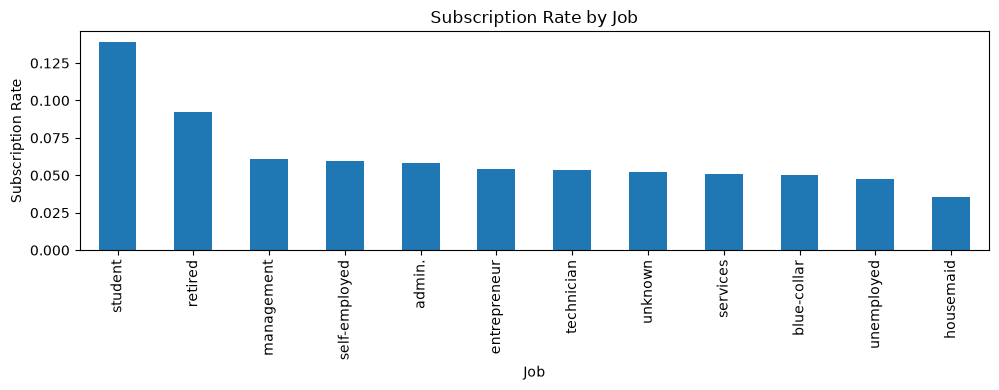

In [57]:
job_target_rate = (
    train_analysis
    .groupby("job")["y_yes"]
    .mean()
    .sort_values(ascending=False)
)

job_target_rate.plot(
    kind="bar",
    figsize=(10, 4),
    title="Subscription Rate by Job",
)

plt.xlabel("Job")
plt.ylabel("Subscription Rate")
plt.tight_layout()
plt.show()

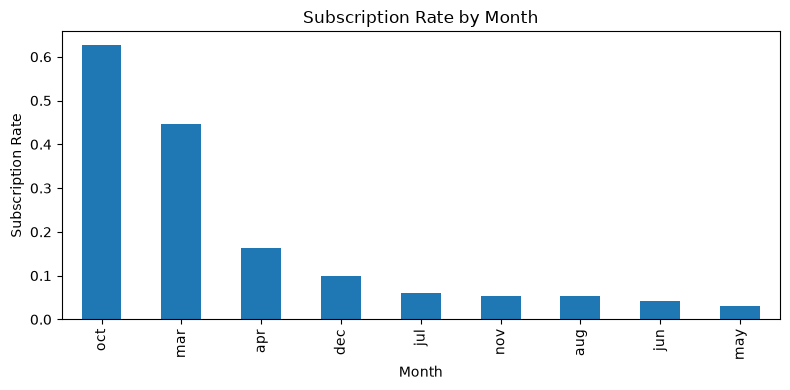

In [58]:
month_target_rate = (
    train_analysis
    .groupby("month")["y_yes"]
    .mean()
    .sort_values(ascending=False)
)

month_target_rate.plot(
    kind="bar",
    figsize=(8, 4),
    title="Subscription Rate by Month",
)

plt.xlabel("Month")
plt.ylabel("Subscription Rate")
plt.tight_layout()
plt.show()

In [59]:
poutcome_target_rate = (
    train_analysis
    .groupby("poutcome")["y_yes"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

poutcome_target_rate

,mean,count
poutcome,,
success,0.140000,50
failure,0.058824,952
nonexistent,0.055446,27829


### Categorical Feature-Target Observations

- `job` shows differences in subscription rates across occupations.
  - `student` has the highest observed subscription rate (13.92%).
  - `retired` also has a relatively high rate (9.22%).
  - Most other occupations are much closer to the overall training positive rate of 5.57%.
  - These relationships are specific to the training period and may change across future temporal regimes.

- `marital` shows relatively modest differences among the major categories.
  - `single` clients have a somewhat higher subscription rate (6.57%) than `married` (5.20%) or `divorced` (5.36%).
  - The `unknown` category has a higher observed rate, but it contains only 49 observations and should not be interpreted strongly.

- `education` shows relatively small differences among the common categories.
  - `university.degree` has the highest rate among the major groups (6.39%).
  - `illiterate` has a high observed rate (14.29%), but this category contains only 14 observations and is too small for a reliable conclusion.

- `default` shows some difference between `no` (6.00%) and `unknown` (4.31%).
  - The `yes` category contains only 3 observations, so its observed target rate is not meaningful.

- `housing` and `loan` show very small differences in subscription rates and appear to have weak individual relationships with the target.

- `contact` shows a clearer difference:
  - `cellular`: 6.99%
  - `telephone`: 4.02%
  This feature may contain useful information, but its availability at the defined prediction time should be confirmed before modeling.

- `month` shows the largest differences in target rates among the categorical features.
  - `oct`, `mar`, and `apr` have substantially higher observed subscription rates.
  - However, some high-rate months have relatively small sample sizes, particularly `oct` and `dec`.
  - The strong relationship with `month` is also likely connected to temporal changes in the campaign and economic environment, so it should not be interpreted as a purely client-level effect.

- `day_of_week` shows relatively small differences, with rates ranging from approximately 4.84% on Monday to 6.43% on Wednesday.

- `poutcome` shows a higher subscription rate following a previous campaign `success` (14.00%).
  - However, only 50 training observations belong to the `success` category.
  - `failure` (5.88%) and `nonexistent` (5.54%) have very similar target rates in the training period.
  - The relationship should be interpreted cautiously because the `success` category contains only 50 training observations.

### 7.2 Numeric Features vs Target

In [60]:
train_df.groupby(target)[numeric_features].mean()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,
no,40.218329,2.785308,997.356400,0.035556,1.023706,93.818485,-39.700639,4.709733,5209.595581
yes,39.485056,2.479452,994.056663,0.041719,0.605479,93.666248,-41.357534,4.274133,5196.411083


In [61]:
train_df.groupby(target)[numeric_features].median()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,
no,39.0,2.0,999.0,0.0,1.4,93.918,-41.8,4.957,5228.1
yes,37.0,2.0,999.0,0.0,1.4,93.918,-42.0,4.957,5228.1


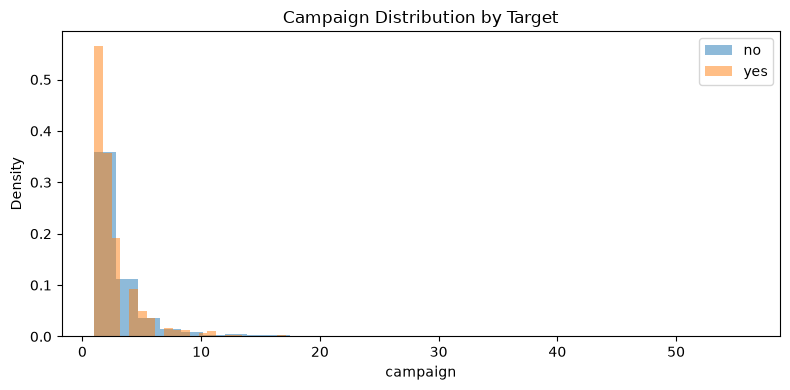

In [62]:
plt.figure(figsize=(8, 4))

for target_value in ["no", "yes"]:
    plt.hist(
        train_df.loc[
            train_df[target] == target_value,
            "campaign",
        ],
        bins=30,
        alpha=0.5,
        density=True,
        label=target_value,
    )

plt.xlabel("campaign")
plt.ylabel("Density")
plt.title("Campaign Distribution by Target")
plt.legend()
plt.tight_layout()
plt.show()

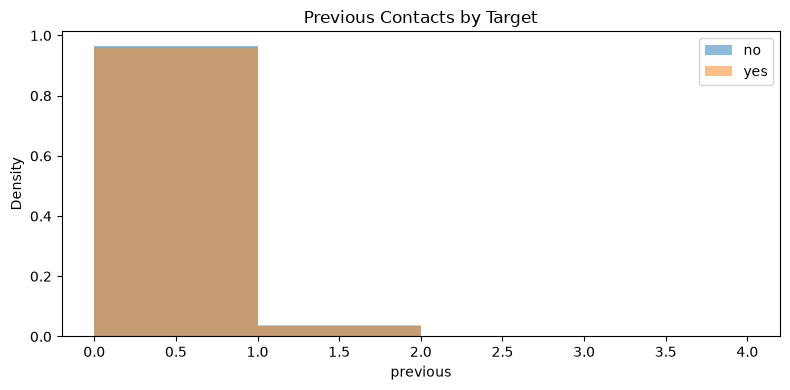

In [63]:
plt.figure(figsize=(8, 4))

for target_value in ["no", "yes"]:
    plt.hist(
        train_df.loc[
            train_df[target] == target_value,
            "previous",
        ],
        bins=range(5),
        alpha=0.5,
        density=True,
        label=target_value,
    )

plt.xlabel("previous")
plt.ylabel("Density")
plt.title("Previous Contacts by Target")
plt.legend()
plt.tight_layout()
plt.show()

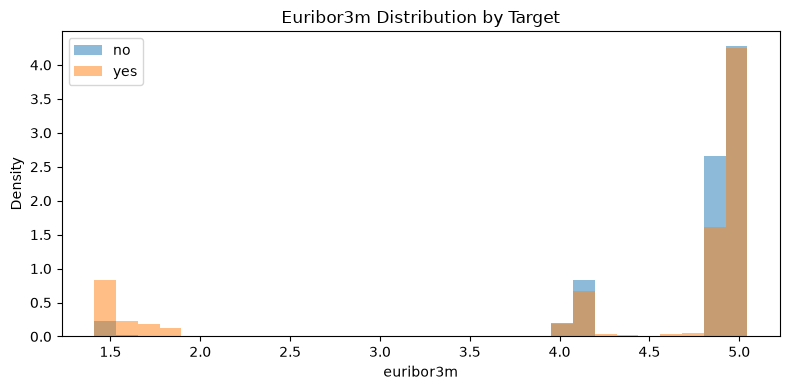

In [64]:
plt.figure(figsize=(8, 4))

for target_value in ["no", "yes"]:
    plt.hist(
        train_df.loc[
            train_df[target] == target_value,
            "euribor3m",
        ],
        bins=30,
        alpha=0.5,
        density=True,
        label=target_value,
    )

plt.xlabel("euribor3m")
plt.ylabel("Density")
plt.title("Euribor3m Distribution by Target")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
pd.crosstab(
    train_df["pdays"].eq(999),
    train_df[target],
    normalize="index",
)

y,no,yes
pdays,,
False,0.849057,0.150943
True,0.944471,0.055529


In [66]:
pdays_observed = train_df[
    train_df["pdays"] != 999
]

pdays_observed.shape

(53, 21)

In [67]:
pdays_observed[target].value_counts()

y
no     45
yes     8
Name: count, dtype: int64

### Numeric Feature-Target Observations

- `age` shows only a modest difference between the target classes.
  - Mean age: 40.22 for `no` and 39.49 for `yes`
  - Median age: 39 for `no` and 37 for `yes`

- `campaign` is slightly lower for subscribed clients.
  - Mean: 2.79 for `no` and 2.48 for `yes`
  - Median: 2 for both classes
  This suggests a modest association rather than a large separation between the target classes.

- `previous` has nearly identical distributions across the target classes.
  - The median is 0 for both classes.
  - The mean is only slightly higher for `yes`.
  Because the feature is highly concentrated at zero, the difference in means should not be overinterpreted.

- `pdays` is dominated by the sentinel value `999` for both target classes.
  - The median is 999 for both classes.
  - Only 53 training observations have `pdays != 999`, of which 8 belong to the positive class.
  - The subscription rate is higher among these observations (15.09%) than among observations with `pdays = 999` (5.55%), but the non-sentinel group is too small for a strong conclusion.

- Several macroeconomic features show noticeable differences in their class-specific means.
  - `emp.var.rate`, `euribor3m`, and `nr.employed` are lower on average for subscribed clients.
  - `cons.price.idx` is also somewhat lower for subscribed clients.
  - `cons.conf.idx` is more negative on average for subscribed clients.

- Despite these mean differences, several macroeconomic features have identical or nearly identical medians across the target classes.
  This reflects their discrete, regime-like temporal structure and indicates that their relationship with the target should be interpreted together with time rather than as ordinary client-level continuous effects.

- These results indicate associations with the target, but they do not by themselves establish feature importance or causal effects.

### Observations

- Several categorical and numeric features show associations with the target, but the strength and reliability of these relationships vary substantially.
- `job` shows some variation in subscription rates, with `student` and `retired` having relatively high rates in the training period, while most occupations remain close to the overall positive rate.
- `housing` and `loan` show relatively small target-rate differences.
- `contact` shows a clearer difference between `cellular` and `telephone`, but its availability at the defined prediction time should be reviewed before modeling.
- `month` shows large differences in subscription rates across categories, although some high-rate months contain relatively few observations. These differences are likely related to temporal campaign and economic conditions.
- `poutcome = success` has a higher observed subscription rate, but the category contains only 50 training observations, so the relationship should be interpreted cautiously.
- Among numeric features, `age`, `campaign`, and `previous` show relatively modest differences between the target classes.
- `pdays` is dominated by the sentinel value `999`. Only 53 observations contain another value, so relationships involving non-sentinel values are based on a very small subgroup.
- Several macroeconomic variables differ noticeably in their class-specific means, particularly `emp.var.rate`, `euribor3m`, and `nr.employed`.
- However, their medians are often identical across target classes, suggesting that the observed differences are connected to temporal economic regimes rather than simple client-level separation.
- Category counts, distribution shape, temporal structure, and feature availability must therefore be considered alongside raw feature-target associations.
- No features are selected, removed, or transformed based solely on the univariate target relationships observed in this section.

## 8. Feature-Feature Analysis

This section examines relationships among modeling features in the training data.

The goals are to:

- identify strongly related numeric features
- detect potentially redundant information
- examine logically related feature groups
- understand whether multiple variables represent the same underlying process
- identify feature relationships that may affect preprocessing or model interpretation

### 8.1 Numeric vs Numeric

In [68]:
corr_matrix = train_df[numeric_features].corr()

corr_matrix

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.012943,0.004963,0.013172,-0.007117,-0.029928,0.055760,-0.000388,-0.004962
campaign,0.012943,1.000000,0.010867,-0.054221,0.122314,0.109266,-0.020164,0.091120,0.114499
pdays,0.004963,0.010867,1.000000,-0.252872,0.096326,0.069062,0.052914,0.088759,0.069865
previous,0.013172,-0.054221,-0.252872,1.000000,-0.397401,-0.291640,-0.207511,-0.354390,-0.271643
emp.var.rate,-0.007117,0.122314,0.096326,-0.397401,1.000000,0.645965,0.461939,0.946480,0.848991
cons.price.idx,-0.029928,0.109266,0.069062,-0.291640,0.645965,1.000000,0.057693,0.564585,0.400755
cons.conf.idx,0.055760,-0.020164,0.052914,-0.207511,0.461939,0.057693,1.000000,0.527574,0.170350
euribor3m,-0.000388,0.091120,0.088759,-0.354390,0.946480,0.564585,0.527574,1.000000,0.852491
nr.employed,-0.004962,0.114499,0.069865,-0.271643,0.848991,0.400755,0.170350,0.852491,1.000000


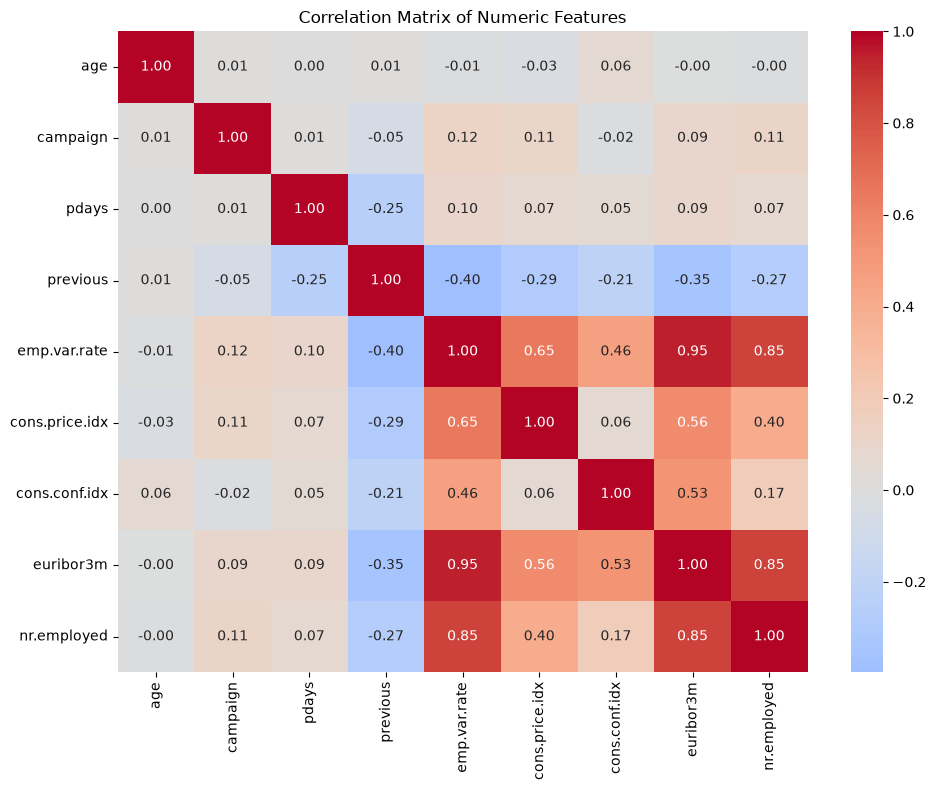

In [69]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [70]:
upper_corr = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1,
        ).astype(bool)
    )
)

strong_correlations = (
    upper_corr
    .stack()
    .rename("correlation")
    .loc[lambda x: x.abs() >= 0.80]
    .sort_values(key=abs, ascending=False)
)

strong_correlations

emp.var.rate  euribor3m      0.946480
euribor3m     nr.employed    0.852491
emp.var.rate  nr.employed    0.848991
Name: correlation, dtype: float64

### Numeric Feature Relationship Observations

- Most client-level and campaign-level numeric features show relatively weak linear correlations with one another.
- Strong correlations are concentrated among the macroeconomic variables.
- The strongest observed relationships are:
  - `emp.var.rate` and `euribor3m`: 0.95
  - `euribor3m` and `nr.employed`: 0.85
  - `emp.var.rate` and `nr.employed`: 0.85
- These strong correlations suggest that the macroeconomic variables share substantial information about the same underlying economic and temporal regime.
- `cons.price.idx` is moderately correlated with `emp.var.rate` (0.65) and `euribor3m` (0.56), while `cons.conf.idx` shows more moderate relationships with the other macroeconomic variables.
- `previous` is negatively associated with several macroeconomic variables, especially `emp.var.rate` (-0.40) and `euribor3m` (-0.35), which may reflect differences in campaign history across temporal periods.
- `pdays` and `previous` have a moderate negative correlation (-0.25), but this value should be interpreted cautiously because `pdays` is dominated by the sentinel value `999`.
- High correlation alone is not used as a reason to remove a feature at this stage.

### 8.2 Categorical ↔ Categorical

In [71]:
job_education = pd.crosstab(
    train_df["job"],
    train_df["education"],
    normalize="index",
)

job_education

education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree,unknown
job,,,,,,,,
admin.,0.007598,0.016463,0.052202,0.308710,0.000141,0.033770,0.555368,0.025749
blue-collar,0.267114,0.153020,0.382849,0.087397,0.001044,0.045339,0.009098,0.054139
entrepreneur,0.098643,0.044344,0.145701,0.168326,0.001810,0.091403,0.414480,0.035294
housemaid,0.454654,0.075179,0.097852,0.164678,0.001193,0.048926,0.116945,0.040573
management,0.036737,0.030057,0.061546,0.113550,0.000000,0.029580,0.685592,0.042939
retired,0.319681,0.047782,0.111490,0.168373,0.000000,0.150171,0.150171,0.052332
self-employed,0.075743,0.022052,0.167785,0.080537,0.002876,0.123682,0.506232,0.021093
services,0.039278,0.054494,0.100849,0.674098,0.000000,0.055556,0.033263,0.042463
student,0.050633,0.008439,0.135021,0.362869,0.000000,0.033755,0.324895,0.084388


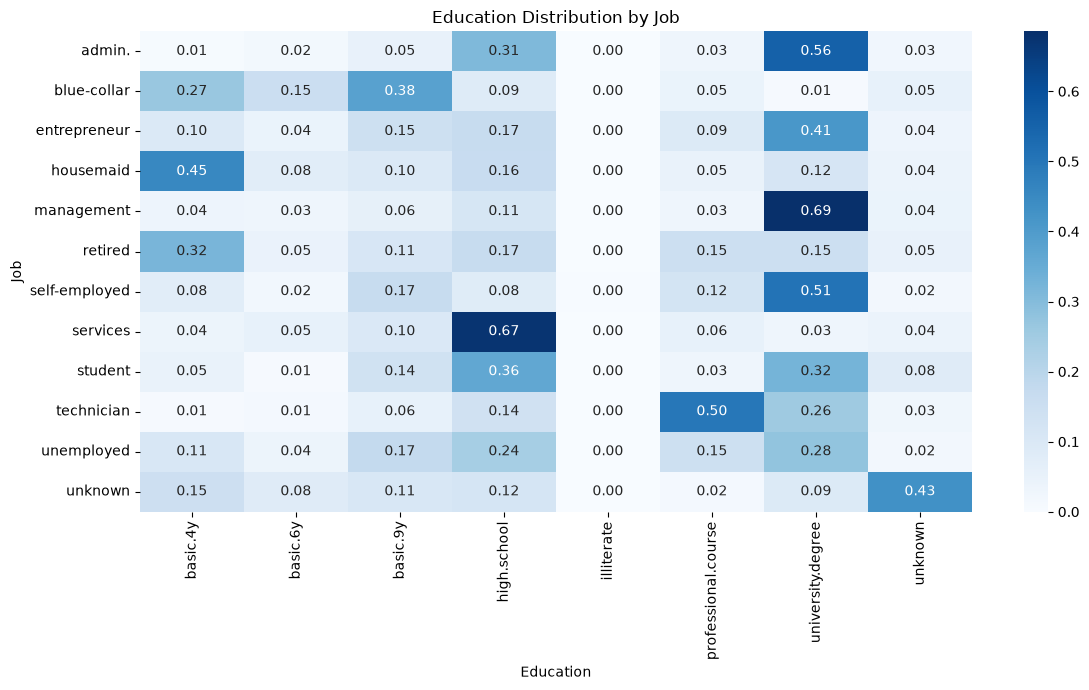

In [72]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    job_education,
    annot=True,
    fmt=".2f",
    cmap="Blues",
)

plt.title("Education Distribution by Job")
plt.xlabel("Education")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

### Job-Education Relationship

The distribution of education varies substantially across job categories.

- `management` is strongly concentrated in `university.degree` (68.56%).
- `admin.` also has a high proportion of `university.degree` (55.54%).
- `blue-collar` workers are concentrated in the basic education categories,
  particularly `basic.9y` (38.28%) and `basic.4y` (26.71%).
- `services` is dominated by `high.school` (67.41%).
- `technician` has a large proportion of `professional.course` (49.78%).
- `housemaid` has a relatively large proportion of `basic.4y` (45.47%).
- The `unknown` job category also has a high proportion of `unknown`
  education (42.97%).

These patterns indicate that `job` and `education` are associated and likely
capture overlapping aspects of a client's socioeconomic background.

However, the two features are not interchangeable. Each still contains
information that is not fully determined by the other, so this relationship
alone is not sufficient reason to remove either feature.

### 8.3 Numeric vs Categorical

In [73]:
job_age_summary = (
    train_df.groupby("job")["age"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .sort_values("median")
)

job_age_summary

,count,mean,median,std
job,,,,
student,237,28.624473,28.0,5.439022
admin.,7107,38.612635,37.0,8.671642
technician,5054,38.950534,37.0,8.404263
services,2826,38.416136,37.0,9.094910
blue-collar,6705,40.125727,39.0,8.908001
unemployed,692,39.813584,39.0,8.709905
self-employed,1043,40.690316,40.0,8.852978
entrepreneur,1105,41.588235,41.0,8.773811
management,2096,42.461355,42.0,8.945469


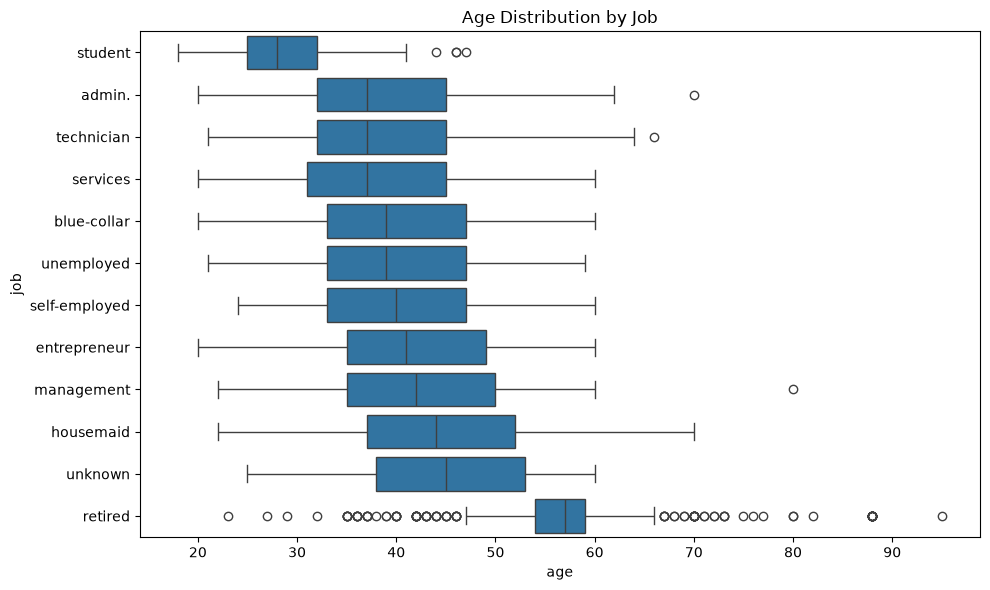

In [74]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="age",
    y="job",
    order=job_age_summary.index,
)

plt.title("Age Distribution by Job")
plt.tight_layout()
plt.show()

### Job-Age Relationship

Age distributions differ noticeably across job categories.

- `student` is clearly concentrated at younger ages, with a median age of 25.
- `retired` is concentrated at older ages, with a median age of 59.
- `admin.`, `services`, and `technician` have relatively younger central ages, with medians between 36 and 37.
- `entrepreneur` and `management` have somewhat higher median ages of 41 and 42, respectively.
- `housemaid` and the `unknown` job category have median ages of 45.
- Most non-student and non-retired job categories still show substantial variation within each group, indicating considerable overlap in age distributions.

These results show that `job` and `age` are associated, particularly for
categories such as `student` and `retired`.

However, age is not determined by job category, and substantial overlap exists
among most occupations. Therefore, the two features contain overlapping but
non-identical information.

### 8.4 Temporal Feature Relationships

In [75]:
month_euribor = (
    train_df
    .groupby("month")["euribor3m"]
    .agg(["count", "mean", "median", "std"])
)

month_euribor

,count,mean,median,std
month,,,,
apr,859,1.439027,1.4350,0.027127
aug,5175,4.964804,4.9640,0.001897
dec,10,3.493400,3.5255,0.230186
jul,6685,4.961587,4.9620,0.002628
jun,4374,4.931639,4.9590,0.044007
mar,282,1.646220,1.6400,0.102071
may,7763,4.857663,4.8570,0.002109
nov,3616,4.114895,4.1200,0.075754
oct,67,4.923776,4.9210,0.081319


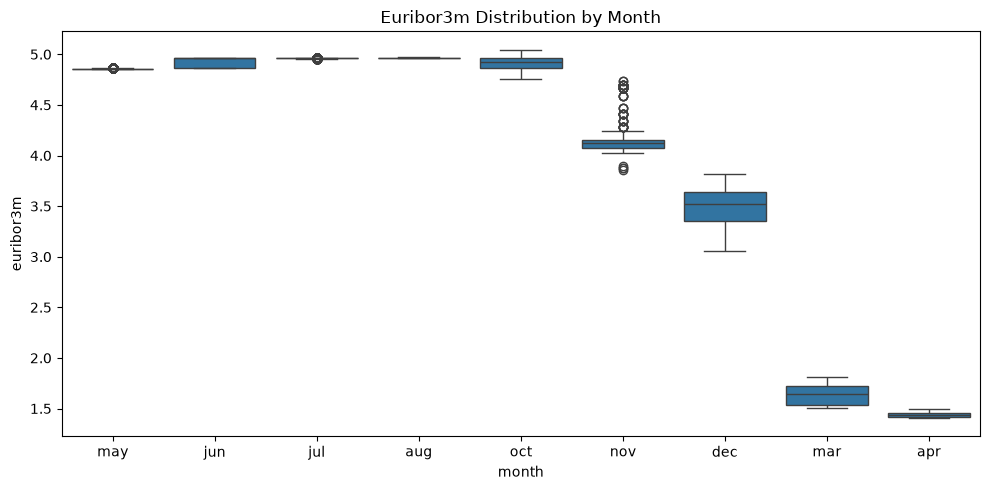

In [76]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=train_df,
    x="month",
    y="euribor3m",
)

plt.title("Euribor3m Distribution by Month")
plt.tight_layout()
plt.show()

### Month-Euribor3m Relationship

`euribor3m` varies substantially across month categories in the training data.

- `apr` and `mar` have relatively low Euribor values, with median values of
  approximately 1.44 and 1.64.
- `nov` has an intermediate median value of approximately 4.12.
- `may`, `jun`, `jul`, `aug`, and `oct` have relatively high median values,
  generally close to 4.9.
- For several high-frequency months, particularly `may`, `jul`, and `aug`,
  the within-month variation is very small.

These results indicate that `month` and `euribor3m` share substantial temporal
information.

However, the relationship is not a simple seasonal pattern. The dataset spans
multiple time periods, and `month` does not contain year information, so a
month category alone cannot uniquely identify the underlying economic regime.

Therefore, `month` and `euribor3m` capture overlapping but non-identical
temporal information.

### 8.5 Previous Campaign History Relationships

In [77]:
pd.crosstab(
    train_df["poutcome"],
    train_df["previous"],
)

previous,0,1,2,3
poutcome,,,,
failure,0,925,26,1
nonexistent,27829,0,0,0
success,0,46,3,1


### Poutcome-Previous Relationship

`poutcome` and `previous` show a strong structural relationship in the
training data.

- Every observation with `poutcome = nonexistent` has `previous = 0`.
- Every observation with `poutcome = failure` or `success` has
  `previous > 0`.
- Most observations with previous campaign history have exactly one previous
  contact.

This indicates that both variables encode whether previous campaign activity
exists.

However, they are not redundant:

- `previous` records the number of previous contacts.
- `poutcome` records the outcome of the previous campaign.

For example, observations with `previous = 1` can belong to either
`failure` or `success`.

Therefore, the two features contain strongly overlapping but non-identical
information.

### Observations

- Most client-level numeric features show relatively weak linear correlations with one another.
- Strong numeric correlations are concentrated among the macroeconomic variables:
  - `emp.var.rate` and `euribor3m`: approximately 0.95
  - `euribor3m` and `nr.employed`: approximately 0.85
  - `emp.var.rate` and `nr.employed`: approximately 0.85
- These strong correlations suggest that the macroeconomic variables capture overlapping aspects of the same underlying economic and temporal regime.
- `cons.price.idx` and `cons.conf.idx` also share some information with this macroeconomic group, although their relationships are weaker.
- Correlations involving `pdays` should be interpreted cautiously because the feature is dominated by the sentinel value `999`.

- `job` and `education` are clearly associated.
  - For example, `management` and `admin.` are concentrated in `university.degree`,
    while `blue-collar`, `services`, and `technician` show different education profiles.
  - However, neither feature fully determines the other, so they should not be considered redundant based on this relationship alone.

- `job` and `age` are also associated.
  - `student` is concentrated at younger ages, while `retired` is concentrated at older ages.
  - Most other job categories show substantial overlap in age distributions.
  - Therefore, `job` and `age` contain overlapping but non-identical demographic information.

- `month` and `euribor3m` share substantial temporal information.
  - Euribor levels differ considerably across month categories.
  - However, `month` does not contain year information and therefore cannot uniquely identify the underlying economic regime.
  - Calendar features and macroeconomic features should therefore be interpreted as overlapping but distinct temporal signals.

- `poutcome` and `previous` show a strong structural relationship.
  - Every observation with `poutcome = nonexistent` has `previous = 0`.
  - Every observation with `poutcome = failure` or `success` has `previous > 0`.
  - However, `previous` records the number of previous contacts, while `poutcome` records their outcome, so the two features are not fully redundant.

- Together with `pdays`, `previous` and `poutcome` form a related feature group describing previous campaign history.

- Strong correlation or structural association alone is not sufficient reason to remove a feature.
- Potential redundancy will be considered later together with model type, validation performance, preprocessing requirements, and interpretability.

## 9. Modeling Decisions

This section converts the findings from the previous analysis into concrete
modeling decisions.

The goals are to:

- finalize the feature set
- review feature availability at prediction time
- define preprocessing requirements
- define evaluation metrics
- define the validation strategy

### 9.1 Feature Availability

The prediction time was defined in Section 1 as immediately before a marketing
call.

Therefore, only information that would reasonably be available at that point
should be used as model input.

#### `duration`

`duration` records the duration of the current marketing call and is only known
after the call has occurred.

Decision:

- Exclude `duration` from all modeling feature sets.


#### Client Information

The following client-level variables are assumed to be available before the call:

- `age`
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`

Decision:

- Keep these features.

#### Previous Campaign History

The following variables describe information from previous campaigns:

- `pdays`
- `previous`
- `poutcome`

These variables are available before the current call and therefore do not
constitute target leakage.

EDA showed that these features are structurally related, particularly
`previous` and `poutcome`.

`pdays` is also dominated by the sentinel value `999`.

Decision:

- Keep these features initially.
- Handle `pdays` carefully during preprocessing.
- Evaluate potential redundancy during modeling rather than removing features
  solely based on EDA.

#### Macroeconomic Variables

The following variables describe the economic environment:

- `emp.var.rate`
- `cons.price.idx`
- `cons.conf.idx`
- `euribor3m`
- `nr.employed`

These values are assumed to be known at prediction time.

EDA showed strong correlations among several of these variables, particularly
`emp.var.rate`, `euribor3m`, and `nr.employed`.

Decision:

- Keep them initially.
- Do not remove variables solely because of correlation.
- Consider multicollinearity when interpreting linear models.

#### `month` and `day_of_week`

These variables describe when the current campaign contact occurs.

If predictions are generated for a known campaign date, both variables are
available before the call.

EDA also showed that `month` shares substantial information with the
macroeconomic variables and acts partly as a temporal signal.

Decision:

- Keep both features initially.
- Interpret their effects as temporal rather than purely client-level effects.
- Ensure preprocessing can handle categories that were not observed in the
  training period.

#### `campaign`

`campaign` records the number of contacts associated with the client during
the current campaign.

Its availability depends on the exact scoring workflow.

If predictions are generated before each contact attempt, the current contact
number can be known from the campaign history.

If the model is instead used once before any campaign contact occurs, this
feature would not yet be available.

Decision:

- Keep `campaign` for the current prediction definition.
- Revisit this decision if the production use case is changed to prediction
  before the first campaign contact.

#### `contact`

`contact` describes the communication channel used for the current contact.

Its validity depends on the operational sequence:

- If the communication channel is selected before scoring, the feature is
  available.
- If clients are scored before the communication channel is selected, the
  feature would not be available.

Decision:

- Treat `contact` as operationally ambiguous.
- Keep it in the initial feature set.
- Compare model performance with and without `contact` as a sensitivity check.

### 9.2 Final Candidate Feature Set

In [78]:
target = "y"
excluded_features = ["duration"]

In [79]:
modeling_features = [
    col
    for col in train_df.columns
    if col not in [target, *excluded_features]
]

len(modeling_features)

19

In [80]:
X_train = train_df[modeling_features].copy()
y_train = train_df[target].copy()

In [81]:
X_valid = valid_df[modeling_features].copy()
y_valid = valid_df[target].copy()

X_test = test_df[modeling_features].copy()
y_test = test_df[target].copy()

In [82]:
X_train.shape, X_valid.shape, X_test.shape

((28831, 19), (8238, 19), (4119, 19))

### 9.3 Preprocessing Decisions

Based on the training-data analysis:

- Numeric and categorical features require separate preprocessing pipelines.
- Categorical features will require encoding.
- The categorical encoder must safely handle categories that were not observed
  during training.
- `"unknown"` values will initially be retained as explicit categories rather
  than converted to missing values.
- `pdays` will not be passed directly to a linear model as an ordinary
  continuous variable.
- A preprocessing alternative that separates the sentinel state from the
  observed recency value will be evaluated during baseline modeling.
- Rare categories will not be manually merged at this stage.
- Extreme values will not be automatically removed or clipped.
- Highly correlated macroeconomic variables will initially be retained.
- All preprocessing steps that learn parameters from data must be fitted on
  the training data only.

### 9.4 Evaluation Metrics

The training target is strongly imbalanced, with only 5.57% positive
observations.

Therefore, accuracy will not be used as the primary evaluation metric.

The main evaluation metrics will include:

- **Average Precision (AP)** as the primary summary metric for positive-class
  ranking under class imbalance
- **ROC-AUC** for overall ranking discrimination
- **Precision** and **Recall** at selected operating points
- **Precision@K**, **Recall@K**, and **Lift@K** for business-oriented ranking
  evaluation

Because the business objective is to prioritize clients when marketing
resources are limited, ranking-based metrics such as precision or recall among
the top-ranked clients will also be considered.

### 9.5 Validation Strategy

The chronological train/validation/test split will be preserved throughout
model development.

- **Train**: fit preprocessing steps and model parameters
- **Validation**: compare models, tune hyperparameters, and select decision rules
- **Test**: perform final evaluation only

The validation and test sets will not be used to fit preprocessing parameters.

After the final model configuration has been selected using the validation set,
the selected pipeline may be refitted using the combined training and
validation data before final evaluation on the test set.

### Observations

- `duration` is excluded because it is not available at the defined prediction time.
- The initial modeling dataset contains 19 candidate input features.
- Client information, previous campaign history, macroeconomic variables,
  `month`, and `day_of_week` are retained initially.
- `campaign` is retained under the current prediction definition but depends
  on the exact operational scoring workflow.
- `contact` remains operationally ambiguous and will be evaluated through a
  sensitivity analysis with and without the feature.
- `"unknown"` values are retained as explicit categories during initial modeling.
- The preprocessing pipeline must support unseen categorical values because
  temporal validation may contain categories not observed during training.
- `pdays` requires special treatment because it is dominated by the sentinel
  value `999`.
- Highly correlated macroeconomic variables are retained initially; their
  redundancy will be evaluated together with model type and validation
  performance.
- Accuracy will not be used as the primary model-selection metric because of
  the strong class imbalance.
- PR-AUC, ROC-AUC, precision, recall, and ranking-based metrics will be used to
  evaluate model performance.
- All preprocessing and model fitting will use the training data only during
  model development.
- The validation set will be used for model and decision-rule selection, while
  the test set will remain reserved for final evaluation.